<center><p float="center">
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center> Real-Time Retail Feedback Intelligence
 </center></h1>


### **Business Context**
During peak sales periods such as holidays and seasonal promotions, ChicStyle experiences a sharp increase in customer orders and review volume. These reviews often contain critical feedback related to product quality, sizing, shipping delays, and overall customer experience. If feedback is not identified and acted on quickly, unresolved issues can escalate into customer dissatisfaction, negative brand perception, lost repeat business, and reduced loyalty. To protect revenue and brand reputation during high-demand periods, the business needs a scalable way to rapidly process large volumes of customer feedback and surface high-priority concerns for timely action.

### **Problem Statement**
Retailers struggle to keep up with large volumes of real-time customer reviews. Traditional NLP often misses nuanced or mixed feedback, causing delays in identifying urgent issues. Generative AI can accurately interpret sentiment and product-specific concerns, enabling faster, more effective responses to protect customer satisfaction and brand reputation.

### **Objective**
Build a Generative AI feedback system that uses prompt engineering techniques—Zero-Shot, Few-Shot, and Chain-of-Thought prompting—to:

Analyze and categorize sentiment in real time

Identify which product or service each feedback refers to

Summarize insights by product category and urgency level

Automatically send short, personalized messages to customers, such as:

Thanking them for positive feedback

Acknowledging neutral comments

Apologizing for negative experiences and informing them a team member will follow up

Generate concise, actionable reports for retail teams

This intelligent system will help retailers quickly act on customer issues, improve product quality faster, and enhance customer satisfaction—transforming massive, unstructured feedback into meaningful, real-time business intelligence.


### **Dataset Used for the Notebook**
This analysis uses the “Women's E-Commerce Clothing Reviews” dataset. The key columns are:

Clothing.ID – A unique identifier for each clothing item

Age – Age of the reviewer (positive integer)

Title – Title of the review (string)

Review.Text – Main body of the customer’s review (string)

Rating – Product score given by the customer, from 1 (worst) to 5 (best) (positive ordinal integer)

Recommended.IND – Binary indicator of whether the customer recommends the product (1 = recommended, 0 = not recommended)

Positive.Feedback.Count – Number of other customers who found the review helpful (positive integer)

Division.Name – High-level division of the product (categorical)

Department.Name – Specific department of the product (categorical)

Class.Name – Specific class of the product (categorical)

### **Installing and Importing Necessary Libraries**
First, let's set up the environment by installing the required Python libraries.

In [ ]:
# Install the required libraries for the project
!pip install pandas matplotlib seaborn
!pip install -q -U google-genai
!pip install openai
!pip install wordcloud
!pip install plotly

**Note:**

After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.


In [61]:
# Importing the necessary libraries
# Mandatory: Run this AFTER restarting the runtime following the installation step.
# --- Core Utilities ---
import time
import json
import re
import numpy as np
from typing import Dict, List, Optional, Any, Tuple

# --- Data Handling ---
import pandas as pd
from google.colab import userdata

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import display

# --- Machine Learning Metrics ---
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# --- Progress Bar ---
from tqdm import tqdm

# --- OpenAI Client ---
import openai

# Set global plot style
sns.set_style("whitegrid")

### **Data Loading**
### Loading and Understanding the Data


In [62]:
# load in the csv file from github repository
raw_github_url = "https://raw.githubusercontent.com/mikejoe144/MIT_Course_Capstone_Project/main/Dataset%20-%20Real-Time%20Retail%20Feedback%20Intelligence.csv" # You will need to fill this in with the actual URL

try:
    data = pd.read_csv(raw_github_url,sep=';')
    print("CSV file loaded successfully!")
except Exception as e:
    print(f"Error loading CSV file: {e}")
    print("Please ensure the URL is correct and points to a raw CSV file.")

CSV file loaded successfully!


In [63]:
# Copying data to another variable to avoid any changes to original data
df = data.copy()

### **Data Overview**

In [64]:
df.head()


,Unnamed: 0,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
0,1,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,2,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,3,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,5,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


### **Sanity checks**

In [65]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing.ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review.Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended.IND          23486 non-null  int64 
 7   Positive.Feedback.Count  23486 non-null  int64 
 8   Division.Name            23472 non-null  object
 9   Department.Name          23472 non-null  object
 10  Class.Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB
None


Checking for missing values

In [66]:
print(df.isnull().sum().sort_values(ascending=False))

Title                      3810
Review.Text                 845
Department.Name              14
Class.Name                   14
Division.Name                14
Unnamed: 0                    0
Clothing.ID                   0
Age                           0
Rating                        0
Recommended.IND               0
Positive.Feedback.Count       0
dtype: int64


Checking for dulicate rows

In [67]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [68]:
display(df.describe(include='all'))

,Unnamed: 0,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
count,23486.000000,23486.000000,23486.000000,19676,22641,23486.000000,23486.000000,23486.000000,23472,23472,23472
unique,NaN,NaN,NaN,13993,22634,NaN,NaN,NaN,3,6,20
top,NaN,NaN,NaN,Love it!,Perfect fit and i've gotten so many compliment...,NaN,NaN,NaN,General,Tops,Dresses
freq,NaN,NaN,NaN,136,3,NaN,NaN,NaN,13850,10468,6319
mean,11743.500000,918.118709,43.198544,NaN,NaN,4.196032,0.822362,2.535936,NaN,NaN,NaN
std,6779.968547,203.298980,12.279544,NaN,NaN,1.110031,0.382216,5.702202,NaN,NaN,NaN
min,1.000000,0.000000,18.000000,NaN,NaN,1.000000,0.000000,0.000000,NaN,NaN,NaN
25%,5872.250000,861.000000,34.000000,NaN,NaN,4.000000,1.000000,0.000000,NaN,NaN,NaN
50%,11743.500000,936.000000,41.000000,NaN,NaN,5.000000,1.000000,1.000000,NaN,NaN,NaN
75%,17614.750000,1078.000000,52.000000,NaN,NaN,5.000000,1.000000,3.000000,NaN,NaN,NaN


### **Data Cleaning and Preprocessing**

**Think about it:** The Review Text column is the most critical feature for our Generative AI model. What should be done with rows where this text is missing?

Because we need the review text to build our model to be able to respond to feedback. we will need to drop the records which don't have review text. this is only 845 out of 23,485 rows (~3.6%) which is a small percent and safe to drop.

In [69]:
#remove null review records
df = df.dropna(subset=['Review.Text'])

In [70]:
#check null counts now
print(df.isnull().sum().sort_values(ascending=False))

Title                      2966
Class.Name                   13
Department.Name              13
Division.Name                13
Age                           0
Unnamed: 0                    0
Clothing.ID                   0
Recommended.IND               0
Rating                        0
Review.Text                   0
Positive.Feedback.Count       0
dtype: int64


this should be fine for null values now

from earlier it looked like Unnamed:0 was just a row number, we won't need that and will remove it for cleanliness

In [71]:
df = df.drop(columns=['Unnamed: 0'])

### **Exploratory Data Analysis**

EDA is an important part of any project involving data. It is important to investigate and understand the data better before building a model with it. A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data. A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions:**

1.  What is the summary statistics of the numerical data? What can you infer about the distribution of Age, Rating, and Positive Feedback Count?
    
2.  How many unique values are there in the categorical columns like Division Name, Department Name, and Class Name?
    
3.  What is the overall distribution of product Rating? Is the dataset skewed towards positive or negative reviews?
    
4.  Which Department Name receives the highest average rating, and which receives the lowest? What might this indicate?
    
5.  What are the most common words found in highly-rated reviews (4-5 stars) versus poorly-rated reviews (1-2 stars)? (Hint: Use Word Clouds). What initial hypotheses can you form about the key drivers of customer satisfaction and dissatisfaction?

Also write your observations for each questions.

**What is the summary statistics of the numerical data? What can you infer about the distribution of Age, Rating, and Positive Feedback Count?**

In [72]:
# Selecting numerical columns and checking the summary statistics
num_cols = df.select_dtypes('number').columns

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Clothing.ID,22641.0,919.332362,202.266874,1.0,861.0,936.0,1078.0,1205.0
Age,22641.0,43.280376,12.326980,18.0,34.0,41.0,52.0,99.0
Rating,22641.0,4.183561,1.115762,1.0,4.0,5.0,5.0,5.0
Recommended.IND,22641.0,0.818868,0.385136,0.0,1.0,1.0,1.0,1.0
Positive.Feedback.Count,22641.0,2.630582,5.786164,0.0,0.0,1.0,3.0,122.0


**Observations:**


The average age of shoppers is 43, the majority being between 34 and 52.

The average rating is good at a 4.2, with most ratings being either 4 or 5.

Most shoppers (81%) would recommend the items they bought.

The average number of other customers who find the feedback helpful is around 3. there are some outlighers, the max being 122, so some reviews may go viral or highly influential



**How many unique values are there in the categorical columns like Division Name, Department Name, and Class Name?**

In [73]:
categorical_cols = ['Division.Name', 'Department.Name', 'Class.Name']

#see the values names in each field
unique_values = {col: df[col].dropna().unique().tolist() for col in categorical_cols}

for col, values in unique_values.items():
    print(f"{col}: {values}\n")

Division.Name: ['Initmates', 'General', 'General Petite']

Department.Name: ['Intimate', 'Dresses', 'Bottoms', 'Tops', 'Jackets', 'Trend']

Class.Name: ['Intimates', 'Dresses', 'Pants', 'Blouses', 'Knits', 'Outerwear', 'Lounge', 'Sweaters', 'Skirts', 'Fine gauge', 'Sleep', 'Jackets', 'Swim', 'Trend', 'Jeans', 'Legwear', 'Shorts', 'Layering', 'Casual bottoms', 'Chemises']



In [74]:
# Number of unique values for each
df[categorical_cols].nunique()

,0
Division.Name,3
Department.Name,6
Class.Name,20


In [75]:
# Group by Department and get unique Class names
dept_class_mapping = df.groupby('Department.Name')['Class.Name'].unique()

# Convert to lists and display
for dept, classes in dept_class_mapping.items():
    print(f"{dept}: {classes.tolist()}")

Bottoms: ['Pants', 'Skirts', 'Jeans', 'Shorts', 'Casual bottoms']
Dresses: ['Dresses']
Intimate: ['Intimates', 'Lounge', 'Sleep', 'Swim', 'Legwear', 'Layering', 'Chemises']
Jackets: ['Outerwear', 'Jackets']
Tops: ['Blouses', 'Knits', 'Sweaters', 'Fine gauge']
Trend: ['Trend']


In [76]:
# Group by Division and get unique Departments
division_dept_mapping = df.groupby('Division.Name')['Department.Name'].unique()

# Display as lists
for division, departments in division_dept_mapping.items():
    print(f"{division}: {departments.tolist()}")

General: ['Dresses', 'Tops', 'Bottoms', 'Jackets', 'Trend']
General Petite: ['Bottoms', 'Tops', 'Dresses', 'Intimate', 'Jackets', 'Trend']
Initmates: ['Intimate']


There are 3 unique divisions names, 6 unique department names,and 20 unique class names.

the 6 departments contains the following class items...

Bottoms: Pants, Skirts, Jeans, Shorts, Casual bottoms

Dresses: Dresses

Intimate: Intimates, Lounge, Sleep, Swim, Legwear, Layering, Chemises

Jackets: Outerwear, Jackets

Tops: Blouses, Knits, Sweaters, Fine gauge

Trend: Trend

**What is the overall distribution of product Rating? Is the dataset skewed towards positive or negative reviews?**

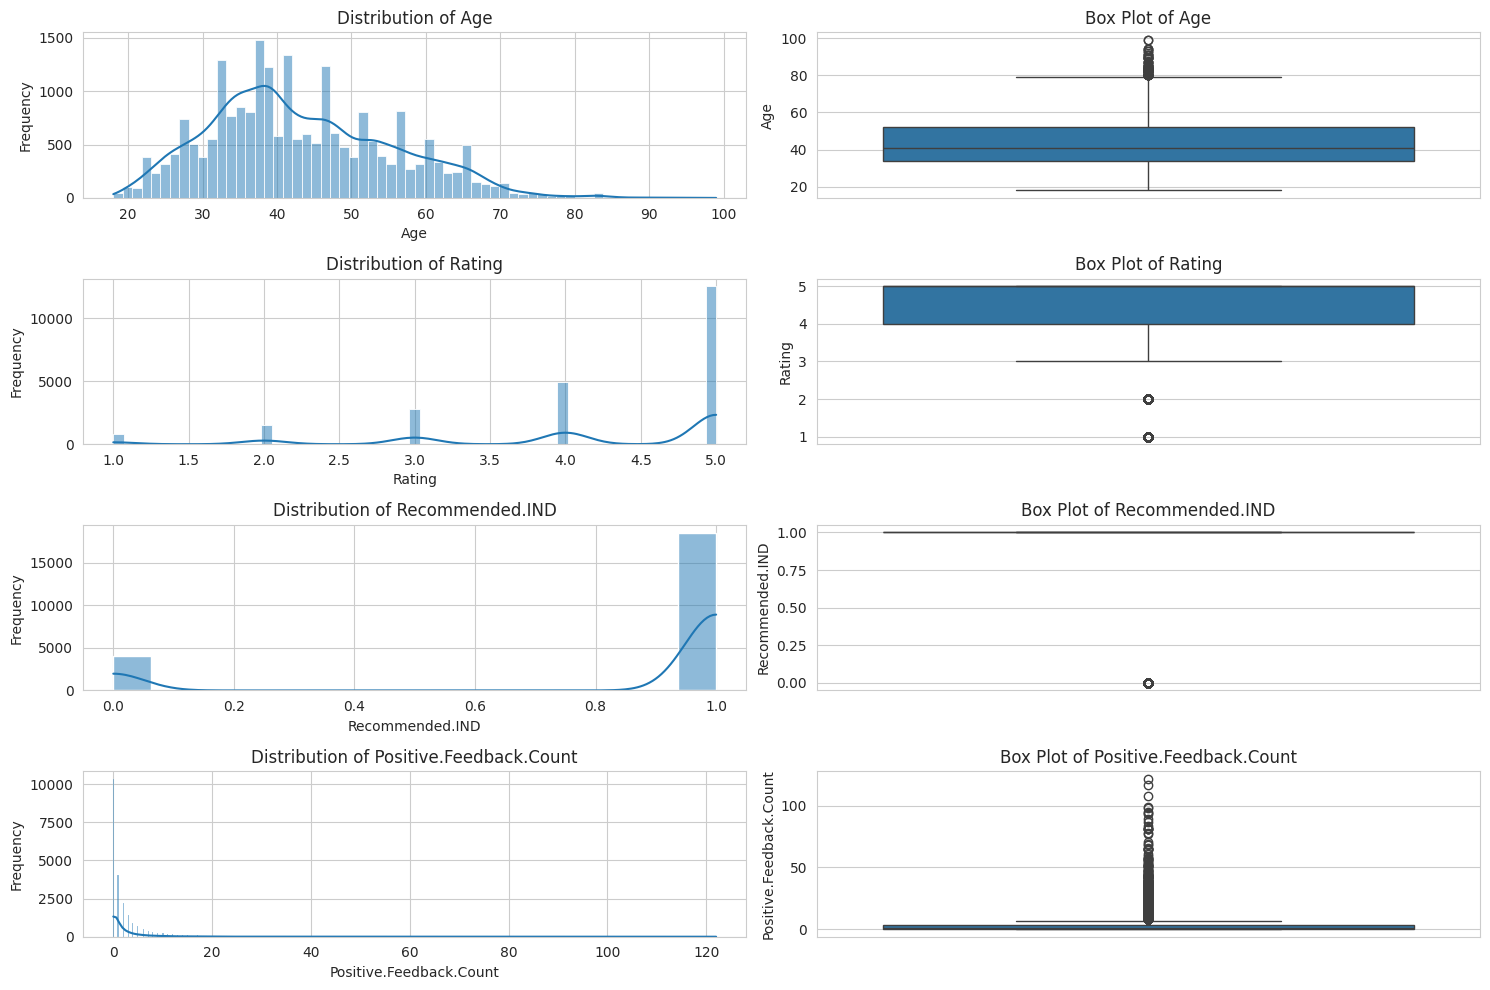

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
# Select numerical columns excluding 'Clothind ID'
num_cols_for_hist = df.select_dtypes(include=np.number).columns.tolist()
if 'Clothing.ID' in num_cols_for_hist:
    num_cols_for_hist.remove('Clothing.ID')


# Loop through the selected numerical columns and plot histograms and boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols_for_hist):
    plt.subplot(len(num_cols_for_hist), 2, i*2 + 1) # Histogram
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.subplot(len(num_cols_for_hist), 2, i*2 + 2) # Boxplot
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

**Observations:**

The product feedback appears to be left skewed. most reviews are positive. to prevent overfitting to positive reviews later when building out the model, we should include some negative reviews in our few-shot prompt later.

**Which Department Name receives the highest average rating, and which receives the lowest? What might this indicate?**

In [78]:
# Group by Department and calculate average rating
dept_avg_rating = df.groupby('Department.Name')['Rating'].mean().reset_index()
dept_avg_rating.rename(columns={'Rating':'Average_Rating'}, inplace=True)
dept_avg_rating

,Department.Name,Average_Rating
0,Bottoms,4.278809
1,Dresses,4.138812
2,Intimate,4.271022
3,Jackets,4.254491
4,Tops,4.157743
5,Trend,3.838983


**Observation**

it appears that the trend department has the worst average ratings, and that bottoms has the highest average ratings. we may need to address the feedback from purchases from the Trend department faster to prevent customer disatisfaction.

In [79]:
# Group by Department and Class, calculate mean rating
class_avg_rating = df.groupby(['Department.Name', 'Class.Name'])['Rating'].mean().reset_index()

# Optional: rename column for clarity
class_avg_rating.rename(columns={'Rating':'Average_Rating'}, inplace=True)
class_avg_rating.head()

,Department.Name,Class.Name,Average_Rating
0,Bottoms,Casual bottoms,4.000000
1,Bottoms,Jeans,4.347826
2,Bottoms,Pants,4.261481
3,Bottoms,Shorts,4.253289
4,Bottoms,Skirts,4.229236


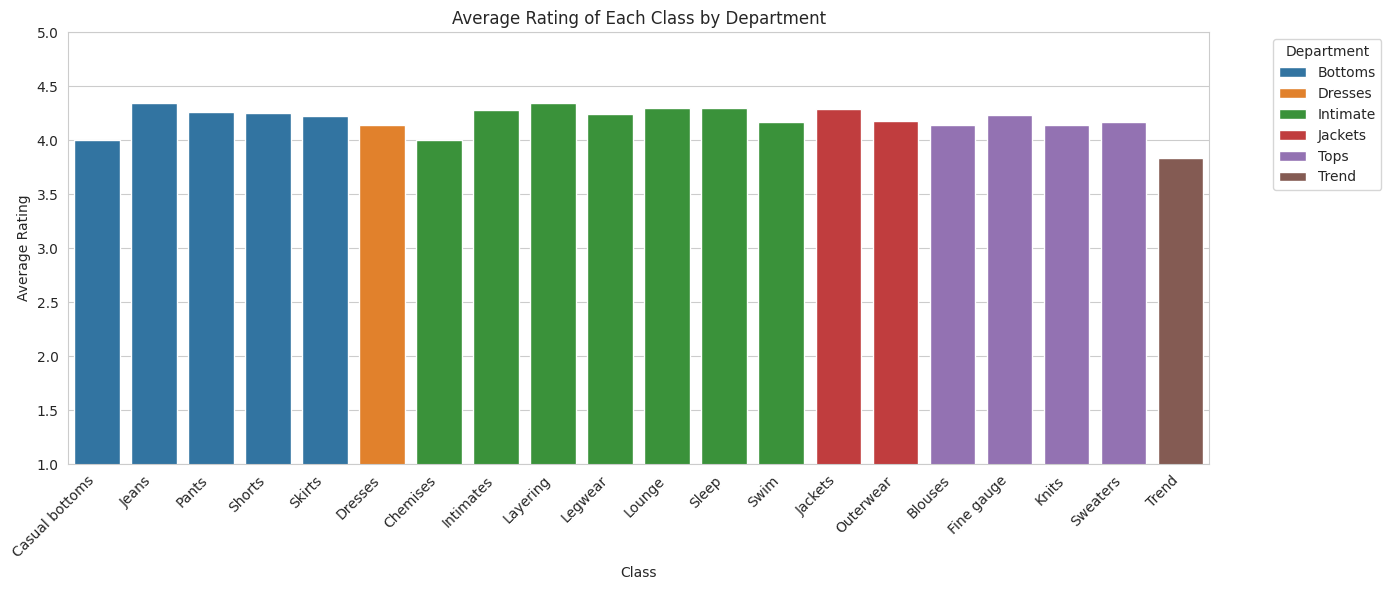

In [80]:
plt.figure(figsize=(14,6))

# Bar plot: Class average rating with department as hue
sns.barplot(
    x='Class.Name',
    y='Average_Rating',
    hue='Department.Name',
    data=class_avg_rating
)

plt.title('Average Rating of Each Class by Department')
plt.xlabel('Class')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Department', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(1,5)  # Ratings are between 1 and 5
plt.tight_layout()
plt.show()

we already knew trend had a low average rating, but from this graph we see that casual bottoms and chemises also have low average ratings. jeans and layering have the 2 highest average ratings it appears.

**What are the most common words found in highly-rated reviews (4-5 stars) versus poorly-rated reviews (1-2 stars)? (Hint: Use Word Clouds). What initial hypotheses can you form about the key drivers of customer satisfaction and dissatisfaction?**

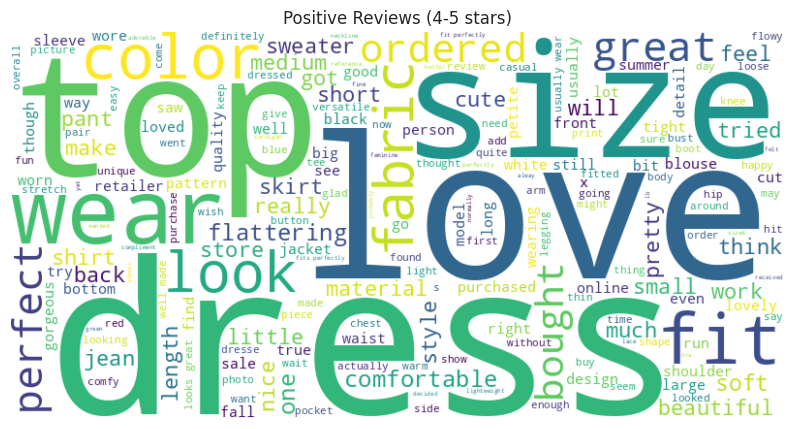

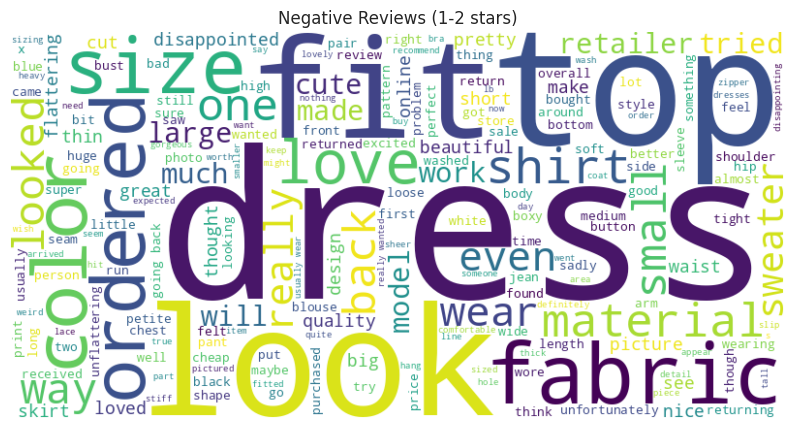

In [81]:
!pip install wordcloud matplotlib
# Positive reviews (4-5 stars)
positive_reviews = df[df['Rating'].isin([4,5])]['Review.Text'].dropna()

# Negative reviews (1-2 stars)
negative_reviews = df[df['Rating'].isin([1,2])]['Review.Text'].dropna()

# Combine all reviews into a single string for word cloud
positive_text = " ".join(positive_reviews)
negative_text = " ".join(negative_reviews)

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Positive reviews word cloud
plt.figure(figsize=(10,6))
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Reviews (4-5 stars)')
plt.show()

# Negative reviews word cloud
plt.figure(figsize=(10,6))
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_text)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Reviews (1-2 stars)')
plt.show()

**Observations:**

dresses and tops appear in both word clouds, maybe those have the most contoversial opinions either people love or hate it. A lot of the same words show up in both word clouds like "fabric", "fit", "size", "look", "color" . these are probably the most common characteristics of the clothing people base their opinions on.

let's try creating word clouds of the negative and positive words to try and get some further insights

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


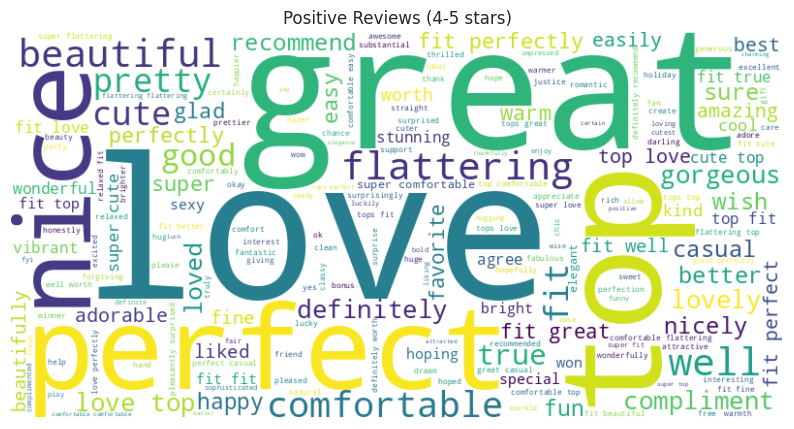

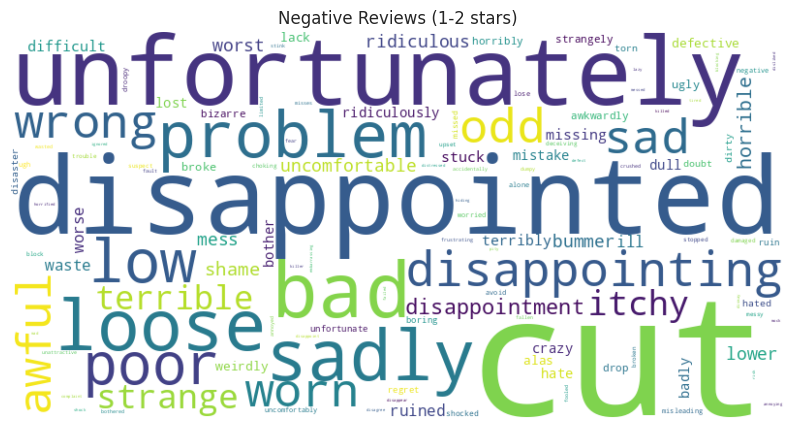

In [82]:
# Install required libraries
!pip install nltk wordcloud matplotlib

# Import libraries
import pandas as pd
import re
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Download VADER lexicon
nltk.download('vader_lexicon')

# Load your data (adjust the path if needed)
# df = pd.read_csv('your_file.csv')

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Function to filter words by sentiment
def sentiment_words(text, sentiment='positive'):
    words = re.findall(r'\b\w+\b', text.lower())  # tokenize
    filtered = []
    for word in words:
        score = sia.polarity_scores(word)['compound']
        if sentiment == 'positive' and score > 0.2:
            filtered.append(word)
        elif sentiment == 'negative' and score < -0.2:
            filtered.append(word)
    return " ".join(filtered)

# Combine review text by rating
positive_text = " ".join(df[df['Rating'].isin([4,5])]['Review.Text'].dropna())
negative_text = " ".join(df[df['Rating'].isin([1,2])]['Review.Text'].dropna())

# Extract sentiment-focused words
positive_filtered = sentiment_words(positive_text, sentiment='positive')
negative_filtered = sentiment_words(negative_text, sentiment='negative')

# Generate word cloud for positive reviews
plt.figure(figsize=(10,6))
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_filtered)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Reviews (4-5 stars)')
plt.show()

# Generate word cloud for negative reviews
plt.figure(figsize=(10,6))
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_filtered)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Reviews (1-2 stars)')
plt.show()

**Observations:**

some of the popular words in the positive reviews are "flattering" and "comfertable".

some of the popular words in the negative reviews are "loose", "cut", "itchy", dissapointment"

## **Building the Generative AI Pipeline**

We will now build a system to analyze the reviews. This involves setting up the AI client, designing prompts, generating structured data, and evaluating the results.

#### **Setup AI Client and Data Sample**

**Questions:**

1.  How do you initialize the OpenAI client with your API key and the correct base URL?
    

#### **Note:**

For this project, we will analyze and categorize a sample of **50 customer reviews**. This number is chosen intentionally. Since the API has a **budget limit of $20**, running prompts on very large datasets can quickly exhaust your quota—especially because this exercise may involve **multiple iterations, prompt refinements, and repeated evaluations**.

To avoid unnecessary cost and ensure efficient experimentation, we recommend the following approach:

*   **Use very small samples (5–10 reviews)** during the **initial testing phase** to validate your prompt structure and logic.
    
*   **Scale up to 50 reviews** for the **final evaluation phase**, ensuring you get enough data to compare prompting techniques without draining your budget.
    
*   This strategy helps maintain cost control while still providing meaningful insights across Zero-Shot, Few-Shot, and Chain-of-Thought techniques.
    

If your API quota gets exhausted, you may temporarily switch to another free AI assistant API. However, note that external tools may also have **rate limits** or **token caps**, so you will need to build retry logic and manage throttling within your code.

In [83]:
# -----------------------------
# Setting up the Gemini Client (Colab-only)
# -----------------------------

from google.colab import userdata   # Colab helper to read secrets
from openai import OpenAI            # OpenAI-compatible client for Gemini

# Read the Gemini API key from Colab Secrets (secret name must match exactly)
gemini_api_key = userdata.get("OPENAI_API_KEY")   # set this secret in Colab as described above

# Instantiate the OpenAI-compatible client pointing to Google's Generative Language endpoint
client = OpenAI(
    api_key=gemini_api_key,
    base_url="https://aibe.mygreatlearning.com/openai/v1"
)

print("Gemini client created. You can now use `client` to call embeddings and chat endpoints.")


Gemini client created. You can now use `client` to call embeddings and chat endpoints.


In [84]:

# List available models
print("Available Models (sample):")
models = client.models.list()
model_ids = [m.id for m in models.data]
print(model_ids[:10], "\n")

''' This uses up usage, don't use again

# 2. Embedding test
print("Embedding test (gemini-embedding-001)...")
emb_resp = client.embeddings.create(
    model="gemini-embedding-001",
    input="This is a test embedding."
)
emb_vector = emb_resp.data[0].embedding
print("Embedding generated. Vector length:", len(emb_vector), "\n")



# 3. Chat completion test
print("Chat completion test (gemini-2.5-flash)...")
chat_resp = client.chat.completions.create(
    model="gemini-2.5-flash",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "Explain to me how AI works in one short sentence."}
    ],
)

# Print the assistant reply text
assistant_text = chat_resp.choices[0].message.content
print("Assistant reply:\n", assistant_text, "\n")

print("=== Sanity Check Completed ===")
'''

Available Models (sample):
['gpt-4-0613', 'gpt-4', 'gpt-3.5-turbo', 'gpt-5.4-mini', 'gpt-5.4', 'gpt-5.4-nano-2026-03-17', 'gpt-5.4-nano', 'gpt-5.4-mini-2026-03-17', 'davinci-002', 'babbage-002'] 



' This uses up usage, don\'t use again\n\n# 2. Embedding test\nprint("Embedding test (gemini-embedding-001)...")\nemb_resp = client.embeddings.create(\n    model="gemini-embedding-001",\n    input="This is a test embedding."\n)\nemb_vector = emb_resp.data[0].embedding\nprint("Embedding generated. Vector length:", len(emb_vector), "\n")\n\n\n\n# 3. Chat completion test\nprint("Chat completion test (gemini-2.5-flash)...")\nchat_resp = client.chat.completions.create(\n    model="gemini-2.5-flash",\n    messages=[\n        {"role": "system", "content": "You are a helpful assistant."},\n        {"role": "user", "content": "Explain to me how AI works in one short sentence."}\n    ],\n)\n\n# Print the assistant reply text\nassistant_text = chat_resp.choices[0].message.content\nprint("Assistant reply:\n", assistant_text, "\n")\n\nprint("=== Sanity Check Completed ===")\n'

In [85]:
#Define which model to use
model='gpt-4'

#### **Prompt Engineering and Evaluation**

We will test three different prompting techniques. For each, we will create a basic version (V1) and an enhanced version (V2).

**Think about it:** Why is it important to have a consistent and robust evaluation framework? How can we use an "LLM-as-Judge" to score the quality of our generated outputs objectively?

#### **Technique 1: Zero-Shot Prompting**

**Questions:**

1.  How would you design a basic Zero-Shot prompt that asks the model for Category, Sentiment, Summary, Personalized Message, and Retail Insight?
    
2.  How can you enhance this prompt with more business context (e.g., a company name, the importance of accuracy) to create a V2 prompt?
    
3.  How will you loop through the data sample to generate and store the structured output for both prompt versions?
    
4.  How will you apply the LLM-as-Judge to generate a evaluation score between 0 to 1 (decimal allowed) for the outputs and calculate the average score of V1 and V2 prompt?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Zero-Shot Prompt Version 1** on a sample of 100 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

In [86]:
#limit sample to 5 reivews for testing
sample_df = df.sample(n=50, random_state=67)
sample_df.head()


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
20344,872,54,Wrong for me,"This is really a cute top, nice fabric, the pr...",3,0,2,General,Tops,Knits
23284,1059,42,Fun multi season pant,Purchased the navy/green and the red/brown. ul...,4,1,0,General,Bottoms,Pants
22995,298,29,Flimsy,Oh what a disappointment! i was looking forwar...,2,0,14,General Petite,Intimate,Lounge
1039,1172,25,NaN,Absolutely love this suit. the bottoms are ver...,5,1,0,Initmates,Intimate,Swim
9437,1094,81,NaN,I really wanted to love this dress. it is abso...,2,0,3,General Petite,Dresses,Dresses


In [87]:
import re
#define the judge
# This evaluates whether the outputs are good. LLM judges are good for subjective scoring
def judge_output(review_text, model_output):

    judge_prompt = f"""
    You are evaluating retail feedback analysis produced by an AI system.

    Evaluate the output on these five dimensions:

    1. Category Accuracy
    2. Sentiment Accuracy
    3. Urgency Accuracy
    4. Personalized Message Quality
    5. Retail Insight Value


    Assign each dimension a score between 0 and 1:
    - 0 = incorrect / poor
    - 1 = excellent
    - decimals allowed (example: 0.75)

    Customer Review:
    {review_text}

    Model Output:
    {model_output}

    Return exactly in this format:

    Category Accuracy: X.XX
    Sentiment Accuracy: X.XX
    Summary Quality: X.XX
    Personalized Message Quality: X.XX
    Retail Insight Value: X.XX
    Overall Score: X.XX

    """

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "user", "content": judge_prompt}
        ],
        temperature=0
    )

    result = response.choices[0].message.content

    # Extract overall score using regex
    match = re.search(r'Overall Score:\s*([0-9.]+)', result)

    if match:
        overall_score = float(match.group(1))
    else:
        overall_score = None

    return result, overall_score

In [88]:
 prompt = f"""
    Analyze this retail customer review and provide the following information. Fill in each field with actual content from the review.

  Category:
  Sentiment:
  Urgency:
  Personalized Message to the customer:
  Retail Insight:


    """

In [89]:
#define zeroshot review
def zero_shot_review(review_text, prompt):

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": prompt},
            {"role": "user", "content": f"Customer Review:\n{review_text}"}
        ],
        temperature=0
    )

    text = response.choices[0].message.content

    # Empty dictionary for structured output
    out = {
        "Category": "",
        "Sentiment": "",
        "Urgency": "",
        "Personalized_Message": "",
        "Retail_Insight": ""
    }

    # Parse line by line
    for line in text.splitlines():
        if ":" in line:
            key, val = line.split(":", 1)
            key = key.strip().lower()
            val = val.strip()

            if key.startswith("category"):
                out["Category"] = val
            elif key.startswith("sentiment"):
                out["Sentiment"] = val
            elif key.startswith("urgency"):
                out["Urgency"] = val
            elif "personal" in key:
                out["Personalized_Message"] = val
            elif "insight" in key:
                out["Retail_Insight"] = val

    return out

In [90]:
#Apply zero-shot function to dataframe
results = sample_df['Review.Text'].apply(
    lambda x: zero_shot_review(x, prompt)
)

In [91]:
#Convert dictionary output into dataframe columns
results_df = pd.DataFrame(results.tolist(), index=sample_df.index)

# Rename columns to indicate source
results_df = results_df.rename(columns={
    'Category': 'V1_zero_shot_Category',
    'Sentiment': 'V1_zero_shot_Sentiment',
    'Urgency': 'V1_zero_shot_Urgency',
    'Personalized_Message': 'V1_zero_shot_Personalized_Message',
    'Retail_Insight': 'V1_zero_shot_Retail_Insight'
})

#Join back to original dataframe
sample_df = pd.concat([sample_df, results_df], axis=1)

#Create one combined model output for judge
sample_df['model_output'] = sample_df.apply(
    lambda row: f"""
Category: {row['V1_zero_shot_Category']}
Sentiment: {row['V1_zero_shot_Sentiment']}
Urgency: {row['V1_zero_shot_Urgency']}
Personalized Message: {row['V1_zero_shot_Personalized_Message']}
Retail Insight: {row['V1_zero_shot_Retail_Insight']}
""",
    axis=1
)


In [92]:
#Apply judge function
sample_df['V1_zero_shot_judge_result'] = sample_df.apply(
    lambda row: judge_output(row['Review.Text'], row['model_output']),
    axis=1
)

#Split judge output into separate columns
sample_df[['V1_zero_shot_judge_text', 'V1_zero_shot_judge_score']] = pd.DataFrame(
    sample_df['V1_zero_shot_judge_result'].tolist(),
    index=sample_df.index
)

In [93]:
sample_df[['Review.Text',
           'V1_zero_shot_Category',
           'V1_zero_shot_Sentiment',
           'V1_zero_shot_Urgency',
           'V1_zero_shot_Personalized_Message',
           'V1_zero_shot_Retail_Insight',
           'V1_zero_shot_judge_score']]

,Review.Text,V1_zero_shot_Category,V1_zero_shot_Sentiment,V1_zero_shot_Urgency,V1_zero_shot_Personalized_Message,V1_zero_shot_Retail_Insight,V1_zero_shot_judge_score
20344,"This is really a cute top, nice fabric, the pr...",Clothing - Women's Tops,Mixed,Low,"Hi there, thank you for your feedback on our t...",The customer appreciates the fabric and print ...,0.80
23284,Purchased the navy/green and the red/brown. ul...,Clothing,Positive,Low,"Hi there, thank you for your detailed review a...",The customer appreciates the versatility and s...,1.00
22995,Oh what a disappointment! i was looking forwar...,Clothing,Negative,High,"Dear customer, we're truly sorry to hear about...",The review indicates a quality issue with the ...,0.95
1039,Absolutely love this suit. the bottoms are ver...,Swimwear,Positive,Not Urgent,Hi there! We're thrilled to hear that you love...,The customer appreciates the comfort and fit o...,1.00
9437,I really wanted to love this dress. it is abso...,Clothing,Negative,Low,"Hi there, we're sorry to hear that the dress d...",The customer found the design of the dress unf...,0.97
1111,Unfortunately i had to size down twice with th...,Clothing - Pants,Mixed,Low,"Hi there, we appreciate your feedback on our p...",The customer is generally satisfied with the p...,0.94
15429,I was excited to try this dress on in person a...,Clothing,Positive,Low,Hi there! We're thrilled to hear that you're h...,The customer appreciates the quality and desig...,0.98
9089,I got the jacket in the gray. it's a pretty pr...,Clothing - Jacket,Positive,Low,"Hi there, we're thrilled to hear that you're p...","The customer is satisfied with the product, pa...",1.00
2046,Should've ordered a larger size. it runs a bit...,Product Size/Quality,Negative,Low,"Dear Customer, we're sorry to hear that the si...",The product may have sizing issues and the zip...,1.00
12139,I am petite so ordered in the store and they s...,Clothing/Fashion,Positive,Low,Hi there! We're thrilled to hear that you're h...,The customer appreciates the store's shipping ...,1.00


In [94]:
#average of the judge score for V1 zero shot prompt is
print("Average Judge Score zero shot V1:", round(sample_df['V1_zero_shot_judge_score'].mean(), 2))

Average Judge Score zero shot V1: 0.96


In [95]:
#create V2 prompt
prompt = """
You are a retail customer feedback analyst.

Analyze customer reviews and return structured business-ready output.

Instructions:
- Determine which product category the review refers to using this list:
  'Intimates', 'Dresses', 'Pants', 'Blouses', 'Knits', 'Outerwear', 'Lounge', 'Sweaters',
  'Skirts', 'Fine gauge', 'Sleep', 'Jackets', 'Swim', 'Trend', 'Jeans', 'Legwear',
  'Shorts', 'Layering', 'Casual bottoms', 'Chemises'

- Identify sentiment as Positive, Neutral, or Negative.

- Generate a short personalized customer response:
    - Positive - thank customer
    - Neutral - acknowledge feedback
    - Negative - apologize and mention follow-up

- Provide one actionable Retail Insight in 1-2 sentences. Be specific and business-focused. Never leave it blank.

Retail insight must be specific and actionable.

Return exactly in this format and do not leave any field empty:

Category:
Sentiment:
Urgency:
Personalized Message:
Retail Insight:


"""

In [96]:
#Apply zero-shot function to dataframe for prompt V2
results = sample_df['Review.Text'].apply(
    lambda x: zero_shot_review(x, prompt)
)

In [97]:
#Convert dictionary output into dataframe columns
results_df = pd.DataFrame(results.tolist(), index=sample_df.index)

# Rename columns to indicate source
results_df = results_df.rename(columns={
    'Category': 'V2_zero_shot_Category',
    'Sentiment': 'V2_zero_shot_Sentiment',
    'Urgency': 'V2_zero_shot_Urgency',
    'Personalized_Message': 'V2_zero_shot_Personalized_Message',
    'Retail_Insight': 'V2_zero_shot_Retail_Insight'
})

#Join back to original dataframe
sample_df = pd.concat([sample_df, results_df], axis=1)

#Create one combined model output for judge
sample_df['model_output'] = sample_df.apply(
    lambda row: f"""
Category: {row['V2_zero_shot_Category']}
Sentiment: {row['V2_zero_shot_Sentiment']}
Urgency: {row['V2_zero_shot_Urgency']}
Personalized Message: {row['V2_zero_shot_Personalized_Message']}
Retail Insight: {row['V2_zero_shot_Retail_Insight']}
""",
    axis=1
)

In [98]:
#Apply judge function
sample_df['V2_zero_shot_judge_result'] = sample_df.apply(
    lambda row: judge_output(row['Review.Text'], row['model_output']),
    axis=1
)

#Split judge output into separate columns
sample_df[['V2_zero_shot_judge_text', 'V2_zero_shot_judge_score']] = pd.DataFrame(
    sample_df['V2_zero_shot_judge_result'].tolist(),
    index=sample_df.index
)

In [99]:
sample_df[['Review.Text',
           'V2_zero_shot_Category',
           'V2_zero_shot_Sentiment',
           'V2_zero_shot_Urgency',
           'V2_zero_shot_Personalized_Message',
           'V2_zero_shot_Retail_Insight',
           'V2_zero_shot_judge_score']]

,Review.Text,V2_zero_shot_Category,V2_zero_shot_Sentiment,V2_zero_shot_Urgency,V2_zero_shot_Personalized_Message,V2_zero_shot_Retail_Insight,V2_zero_shot_judge_score
20344,"This is really a cute top, nice fabric, the pr...",Blouses,Neutral,Low,Thank you for your feedback. We're sorry to he...,Consider offering blouses in different lengths...,0.95
23284,Purchased the navy/green and the red/brown. ul...,Pants,Positive,Low,Thank you for your positive feedback! We're gl...,The customer appreciates the versatility and s...,0.97
22995,Oh what a disappointment! i was looking forwar...,Layering,Negative,High,We're truly sorry to hear about your disappoin...,The quality control team needs to review the m...,0.95
1039,Absolutely love this suit. the bottoms are ver...,Swim,Positive,Low,We're thrilled to hear that you love our swim ...,"The positive feedback on the swim suit, especi...",1.00
9437,I really wanted to love this dress. it is abso...,Dresses,Neutral,Low,Thank you for your feedback. We're sorry to he...,Consider designing dresses with varying neckli...,0.90
1111,Unfortunately i had to size down twice with th...,Pants,Neutral,Low,Thank you for your feedback. We're sorry to he...,Consider reviewing the sizing guide for our pa...,0.95
15429,I was excited to try this dress on in person a...,Dresses,Positive,Low,We're thrilled to hear that you loved the dres...,The dress's soft material and waist-accentuati...,1.00
9089,I got the jacket in the gray. it's a pretty pr...,Jackets,Positive,Low,Thank you for your positive feedback on our gr...,The positive feedback on the gray jacket indic...,1.00
2046,Should've ordered a larger size. it runs a bit...,Dresses,Neutral,Low,Thank you for your feedback. We're sorry to he...,Consider reviewing the sizing guide for dresse...,0.90
12139,I am petite so ordered in the store and they s...,Jeans,Positive,Low,Thank you for your positive feedback! We're gl...,The petite size jeans are well-received by cus...,1.00


In [100]:
#average of the judge score for V2 zero shot prompt is
print("Average Judge Score zero shot V2:", round(sample_df['V2_zero_shot_judge_score'].mean(), 2))

Average Judge Score zero shot V2: 0.95


#### **Technique 2: Few-Shot Prompting**

**Questions:**

1.  How do you structure a Few-Shot prompt? What kind of examples (e.g., one positive, one negative) would be most effective?
    
2.  For the V2 prompt, how can you add a set of "rules" to guide the model's output for each field, reducing ambiguity?
    
3.  After generating and scoring the outputs, how does the performance of Few-Shot prompting compare to previous version?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your ** Prompt Version 1** on a sample of 100 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

In [101]:
#find example reviews to use, a positive, a negative, and a neutral example
#pull 2 examples from each rating group

neg_examples = df[df['Rating'].isin([1, 2])].sample(2, random_state=42)
neutral_examples = df[df['Rating'] == 3].sample(2, random_state=42)
pos_examples = df[df['Rating'].isin([4, 5])].sample(2, random_state=85)

#combine them
few_shot_examples = pd.concat([neg_examples, neutral_examples, pos_examples])

#view the examples
few_shot_examples


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
10858,743,31,NaN,This nightgown looked so comfy and cute! i ord...,2,0,3,Initmates,Intimate,Intimates
1809,867,39,"Droopy front, heavy fabric","Right out of the bag, this top didn't really m...",1,0,8,General,Tops,Knits
9017,872,53,Poorly made,I wanted to love this. it is so cute and the x...,3,0,5,General,Tops,Knits
19121,1121,31,"Beautiful, dramatic trench, but impractical up...","This trench is beautiful, with a lovely, swing...",3,0,5,General,Jackets,Outerwear
18049,1056,56,Super soft & comfy,"Love these chinos, super soft and amazingly co...",5,1,0,General,Bottoms,Pants
10039,1037,49,Love!,I absolutely love the look and fit of these pa...,5,1,0,General,Bottoms,Jeans


In [102]:
#negative review example

few_shot_example_neg_review='''
The fabric and colors of this dress are beautiful but the fit is terrible.
i had to go up a size to get a fit in the waist but it was then incredibly loose in the shoulders.
what a pity. had to return.
'''

few_shot_example_neg_review_response='''
Category: Dresses
Sentiment: Negative
Urgency: Medium
Personalized Message: We're sorry the fit did not meet your expectations despite the fabric and color being appealing.
We appreciate your feedback and a team member will review the sizing concern.
Retail Insight: Conflicting fit across waist and shoulders suggests inconsistent garment grading; review sizing specifications and fit testing to reduce return risk.
'''

#neutral review example
few_shot_example_neu_review='''
It was way to heavy and big for someone with a petite frame like me.
i really liked the design and thought since it came in petite, i'd try it.
it would probably be better on someone much taller but the material is still too heavy.
'''

few_shot_example_neu_review_response='''
Category: Jeans
Sentiment: Neutral
Urgency: Medium
Personalized Message: Thank you for your feedback. We're glad you liked the design and appreciate your comments about fit and fabric weight, which will help us improve future products.
Retail Insight: Petite sizing may not fully account for fabric weight and garment proportions; review petite fit standards and material selection for smaller body frames.
'''

#positive review example
few_shot_example_pos_review='''
This dress is incredible! let me say that when it first arrived, i was terrified that i looked like a got tangled in my grandma's curtain.
the print was really overwhelming for my living room.
however, i went with my gut and wore this dress for our engagement photos out in the woods.
not only was in incredibly flattering, it photographed better than i could have imagined.
wouldn't recommend wearing this grocery shopping but this is a perfect for a special occasion!
'''

few_shot_example_pos_review_response='''
Category: Dresses
Sentiment: Positive
Urgency: Low
Personalized Message: Thank you for sharing your experience!
We're so glad the dress exceeded your expectations and worked beautifully for such a special occasion—congratulations on your engagement photos.
Retail Insight: Bold prints may create hesitation at first impression but perform strongly in occasion-based use;
marketing this item for events and photography could improve conversion.
'''



In [103]:
#define few shot review (same as zero shot just renamed the function)
def few_shot_review(review_text, prompt):

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": prompt},
            {"role": "user", "content": f"Customer Review:\n{review_text}"}
        ],
        temperature=0
    )

    text = response.choices[0].message.content

    # Empty dictionary for structured output
    out = {
        "Category": "",
        "Sentiment": "",
        "Urgency": "",
        "Personalized_Message": "",
        "Retail_Insight": ""
    }

    # Parse line by line
    for line in text.splitlines():
        if ":" in line:
            key, val = line.split(":", 1)
            key = key.strip().lower()
            val = val.strip()

            if key.startswith("category"):
                out["Category"] = val
            elif key.startswith("sentiment"):
                out["Sentiment"] = val
            elif key.startswith("urgency"):
                out["Urgency"] = val
            elif "personal" in key:
                out["Personalized_Message"] = val
            elif "insight" in key:
                out["Retail_Insight"] = val

    return out

In [104]:
few_shot_prompt_V1 = f"""
  Analyze this retail customer review and provide the following information. Fill in each field with actual content from the review.

  Category:
  Sentiment:
  Urgency:
  Personalized Message to the customer:
  Retail Insight:


Examples:

Review: {few_shot_example_neg_review}
Response: {few_shot_example_neg_review_response}

Review: {few_shot_example_neu_review}
Response: {few_shot_example_neu_review_response}

Review: {few_shot_example_pos_review}
Response: {few_shot_example_pos_review_response}

Now analyze the next review:

    """

In [105]:
#Apply few-shot function to dataframe
few_shot_results = sample_df['Review.Text'].apply(
    lambda x: few_shot_review(x, prompt)
)

In [106]:
#Convert dictionary output into dataframe columns
few_shot_results_df = pd.DataFrame(few_shot_results.tolist(), index=sample_df.index)

# Rename columns to indicate source
few_shot_results_df = few_shot_results_df.rename(columns={
    'Category': 'V1_few_shot_Category',
    'Sentiment': 'V1_few_shot_Sentiment',
    'Urgency': 'V1_few_shot_Urgency',
    'Personalized_Message': 'V1_few_shot_Personalized_Message',
    'Retail_Insight': 'V1_few_shot_Retail_Insight'
})

#Join back to original dataframe
sample_df = pd.concat([sample_df,few_shot_results_df], axis=1)

#Create one combined model output for judge
sample_df['model_output'] = sample_df.apply(
    lambda row: f"""
Category: {row['V1_few_shot_Category']}
Sentiment: {row['V1_few_shot_Sentiment']}
Urgency: {row['V1_few_shot_Urgency']}
Personalized Message: {row['V1_few_shot_Personalized_Message']}
Retail Insight: {row['V1_few_shot_Retail_Insight']}
""",
    axis=1
)

In [107]:
#Apply judge function
sample_df['V1_few_shot_judge_result'] = sample_df.apply(
    lambda row: judge_output(row['Review.Text'], row['model_output']),
    axis=1
)

#Split judge output into separate columns
sample_df[['V1_few_shot_judge_text', 'V1_few_shot_judge_score']] = pd.DataFrame(
    sample_df['V1_few_shot_judge_result'].tolist(),
    index=sample_df.index
)

In [108]:
sample_df[['Review.Text',
           'V1_few_shot_Category',
           'V1_few_shot_Sentiment',
           'V1_few_shot_Urgency',
           'V1_few_shot_Personalized_Message',
           'V1_few_shot_Retail_Insight',
           'V1_few_shot_judge_score']]

,Review.Text,V1_few_shot_Category,V1_few_shot_Sentiment,V1_few_shot_Urgency,V1_few_shot_Personalized_Message,V1_few_shot_Retail_Insight,V1_few_shot_judge_score
20344,"This is really a cute top, nice fabric, the pr...",Blouses,Neutral,Low,Thank you for your feedback. We're sorry to he...,Consider offering blouses in different lengths...,0.90
23284,Purchased the navy/green and the red/brown. ul...,Pants,Positive,Low,Thank you for your positive feedback! We're gl...,The customer appreciates the slimming fit and ...,0.96
22995,Oh what a disappointment! i was looking forwar...,Layering,Negative,High,We're truly sorry to hear about your disappoin...,The quality control team needs to review the m...,0.95
1039,Absolutely love this suit. the bottoms are ver...,Swim,Positive,Low,We're thrilled to hear that you love our swim ...,"The positive feedback on the swim suit, especi...",1.00
9437,I really wanted to love this dress. it is abso...,Dresses,Neutral,Low,Thank you for your feedback. We're sorry to he...,Consider designing dresses with different neck...,0.75
1111,Unfortunately i had to size down twice with th...,Pants,Neutral,Low,Thank you for your feedback. We're sorry to he...,Consider reviewing and potentially adjusting t...,0.75
15429,I was excited to try this dress on in person a...,Dresses,Positive,Low,Thank you for your positive feedback! We're th...,"Customers appreciate the soft, comfortable mat...",1.00
9089,I got the jacket in the gray. it's a pretty pr...,Jackets,Positive,Low,Thank you for your positive feedback on our gr...,The positive feedback on the gray jacket indic...,1.00
2046,Should've ordered a larger size. it runs a bit...,Dresses,Neutral,Low,Thank you for your feedback. We're sorry to he...,Consider reviewing the sizing guide for dresse...,0.90
12139,I am petite so ordered in the store and they s...,Jeans,Positive,Low,Thank you for your positive feedback! We're gl...,The review indicates that our petite jeans are...,1.00


In [109]:
#average of the judge score for V1 few shot prompt is
print("Average Judge Score few shot V1:", round(sample_df['V1_few_shot_judge_score'].mean(), 2))

Average Judge Score few shot V1: 0.94


In [110]:
#Create V2 Few shot prompt
few_shot_prompt_V2 = f"""
You are a retail customer feedback analyst.

Analyze customer reviews and return structured business-ready output.

Instructions:
- Determine which product category the review refers to using this list:
  'Intimates', 'Dresses', 'Pants', 'Blouses', 'Knits', 'Outerwear', 'Lounge', 'Sweaters',
  'Skirts', 'Fine gauge', 'Sleep', 'Jackets', 'Swim', 'Trend', 'Jeans', 'Legwear',
  'Shorts', 'Layering', 'Casual bottoms', 'Chemises'

- Identify sentiment as Positive, Neutral, or Negative.

- Generate a short personalized customer response:
    - Positive - thank customer
    - Neutral - acknowledge feedback
    - Negative - apologize and mention follow-up

- Provide one actionable Retail Insight in 1-2 sentences. Be specific and business-focused. Never leave it blank.

Retail insight must be specific and actionable.

Return exactly in this format and do not leave any field empty:

Category:
Sentiment:
Urgency:
Personalized Message:
Retail Insight:


Examples:

Review: {few_shot_example_neg_review}
Response: {few_shot_example_neg_review_response}

Review: {few_shot_example_neu_review}
Response: {few_shot_example_neu_review_response}

Review: {few_shot_example_pos_review}
Response: {few_shot_example_pos_review_response}

Now analyze the next review:

    """

In [111]:
#Apply few-shot function to dataframe
few_shot_results_V2 = sample_df['Review.Text'].apply(
    lambda x: few_shot_review(x, prompt)
)

In [112]:
#Convert dictionary output into dataframe columns
few_shot_results_V2_df = pd.DataFrame(few_shot_results_V2.tolist(), index=sample_df.index)

# Rename columns to indicate source
few_shot_results_V2_df = few_shot_results_V2_df.rename(columns={
    'Category': 'V2_few_shot_Category',
    'Sentiment': 'V2_few_shot_Sentiment',
    'Urgency': 'V2_few_shot_Urgency',
    'Personalized_Message': 'V2_few_shot_Personalized_Message',
    'Retail_Insight': 'V2_few_shot_Retail_Insight'
})

#Join back to original dataframe
sample_df = pd.concat([sample_df,few_shot_results_V2_df], axis=1)

#Create one combined model output for judge
sample_df['model_output'] = sample_df.apply(
    lambda row: f"""
Category: {row['V2_few_shot_Category']}
Sentiment: {row['V2_few_shot_Sentiment']}
Urgency: {row['V2_few_shot_Urgency']}
Personalized Message: {row['V2_few_shot_Personalized_Message']}
Retail Insight: {row['V2_few_shot_Retail_Insight']}
""",
    axis=1
)

In [113]:
#Apply judge function
sample_df['V2_few_shot_judge_result'] = sample_df.apply(
    lambda row: judge_output(row['Review.Text'], row['model_output']),
    axis=1
)

#Split judge output into separate columns
sample_df[['V2_few_shot_judge_text', 'V2_few_shot_judge_score']] = pd.DataFrame(
    sample_df['V2_few_shot_judge_result'].tolist(),
    index=sample_df.index
)

In [114]:
sample_df[['Review.Text',
           'V2_few_shot_Category',
           'V2_few_shot_Sentiment',
           'V2_few_shot_Urgency',
           'V2_few_shot_Personalized_Message',
           'V2_few_shot_Retail_Insight',
           'V2_few_shot_judge_text',
           'V2_few_shot_judge_score']]

,Review.Text,V2_few_shot_Category,V2_few_shot_Sentiment,V2_few_shot_Urgency,V2_few_shot_Personalized_Message,V2_few_shot_Retail_Insight,V2_few_shot_judge_text,V2_few_shot_judge_score
20344,"This is really a cute top, nice fabric, the pr...",Blouses,Neutral,Low,Thank you for your feedback on our blouse. We ...,Consider offering blouses in different lengths...,Category Accuracy: 1.00\nSentiment Accuracy: 0...,0.90
23284,Purchased the navy/green and the red/brown. ul...,Pants,Positive,Low,Thank you for your positive feedback! We're gl...,The customer's feedback suggests that our pant...,Category Accuracy: 1.00\nSentiment Accuracy: 1...,0.76
22995,Oh what a disappointment! i was looking forwar...,Layering,Negative,High,We're truly sorry to hear about your disappoin...,The quality control team needs to review the m...,Category Accuracy: 1.00\nSentiment Accuracy: 1...,0.95
1039,Absolutely love this suit. the bottoms are ver...,Swim,Positive,Low,We're thrilled to hear that you love our swim ...,"The positive feedback on the swim suit, especi...",Category Accuracy: 1.00\nSentiment Accuracy: 1...,1.00
9437,I really wanted to love this dress. it is abso...,Dresses,Neutral,Low,Thank you for your feedback. We're sorry to he...,Consider designing dresses with varying neckli...,Category Accuracy: 1.00\nSentiment Accuracy: 0...,0.95
1111,Unfortunately i had to size down twice with th...,Pants,Neutral,Low,Thank you for your feedback. We're sorry to he...,Consider reviewing the sizing guide for our pa...,Category Accuracy: 1.00\nSentiment Accuracy: 0...,0.95
15429,I was excited to try this dress on in person a...,Dresses,Positive,Low,We're thrilled to hear that you loved the dres...,The dress's soft material and waist-accentuati...,Category Accuracy: 1.00\nSentiment Accuracy: 1...,1.00
9089,I got the jacket in the gray. it's a pretty pr...,Jackets,Positive,Low,We're thrilled to hear that you're pleased wit...,The positive feedback on the gray jacket indic...,Category Accuracy: 1.00\nSentiment Accuracy: 1...,1.00
2046,Should've ordered a larger size. it runs a bit...,Dresses,Neutral,Low,Thank you for your feedback. We're sorry to he...,Consider reviewing the sizing guide for dresse...,Category Accuracy: 1.00\nSentiment Accuracy: 0...,0.95
12139,I am petite so ordered in the store and they s...,Jeans,Positive,Low,Thank you for your positive feedback! We're gl...,The positive feedback on the fit and lightweig...,Category Accuracy: 1.00\nSentiment Accuracy: 1...,1.00


In [115]:
#average of the judge score for V2 few shot prompt is
print("Average Judge Score few shot V2:", round(sample_df['V2_few_shot_judge_score'].mean(), 2))

Average Judge Score few shot V2: 0.95


**observation:**

Few shot judge score was higher than zero shot judge score

#### **Technique 3: Chain-of-Thought (CoT) Prompting**

**Questions:**

1.  How do you instruct the model to "think step-by-step" internally but only show the final, structured answer?
    
2.  How can you combine the CoT instruction with more detailed reasoning from the COT V1 prompt to create a powerful CoT V2 prompt?
    
3.  Does encouraging the model to reason first lead to a measurable improvement in the quality of the generated insights?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Prompt Version 1** on a sample of 100 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

In [116]:
#define CoT review (same as zero shot just renamed the function)
def CoT_review(review_text, prompt):

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": prompt},
            {"role": "user", "content": f"Customer Review:\n{review_text}"}
        ],
        temperature=0
    )

    text = response.choices[0].message.content

    # Empty dictionary for structured output
    out = {
        "Category": "",
        "Sentiment": "",
        "Urgency": "",
        "Personalized_Message": "",
        "Retail_Insight": ""
    }

    # Parse line by line
    for line in text.splitlines():
        if ":" in line:
            key, val = line.split(":", 1)
            key = key.strip().lower()
            val = val.strip()

            if key.startswith("category"):
                out["Category"] = val
            elif key.startswith("sentiment"):
                out["Sentiment"] = val
            elif key.startswith("urgency"):
                out["Urgency"] = val
            elif "personal" in key:
                out["Personalized_Message"] = val
            elif "insight" in key:
                out["Retail_Insight"] = val

    return out

In [117]:
CoT_prompt_V1='''
You are a retail customer feedback analyst.

Analyze the customer review and provide structured, business-ready output.

Instructions:
- Think through the review carefully before answering.
- Step 1: Identify all issues or praises mentioned in the review.
- Step 2: Determine which product category the feedback refers to.
- Step 3: Assess sentiment.
- Step 4: Determine the urgency of the issue.
- Step 5: Generate a short personalized customer response:
- Step 6: Generate one actionable retail insight:

Now analyze the following customer review step by step and return the final structured output:

Return exactly in this format:

Reasoning Steps:
- Step 1:
- Step 2:
- Step 3:
- Step 4:
- Step 5:
- Step 6:

Final Structured Output:
Category:
Sentiment:
Urgency:
Personalized Message:
Retail Insight:
'''

In [118]:
#Apply few-shot function to dataframe
CoT_results_V1 = sample_df['Review.Text'].apply(
    lambda x: CoT_review(x, CoT_prompt_V1)
)

In [119]:
#Convert dictionary output into dataframe columns
CoT_results_V1_df = pd.DataFrame(CoT_results_V1.tolist(), index=sample_df.index)

# Rename columns to indicate source
CoT_results_V1_df = CoT_results_V1_df.rename(columns={
    'Category': 'V1_CoT_Category',
    'Sentiment': 'V1_CoT_Sentiment',
    'Urgency': 'V1_CoT_Urgency',
    'Personalized_Message': 'V1_CoT_Personalized_Message',
    'Retail_Insight': 'V1_CoT_Retail_Insight'
})

#Join back to original dataframe
sample_df = pd.concat([sample_df,CoT_results_V1_df], axis=1)

#Create one combined model output for judge
sample_df['model_output'] = sample_df.apply(
    lambda row: f"""
Category: {row['V1_CoT_Category']}
Sentiment: {row['V1_CoT_Sentiment']}
Urgency: {row['V1_CoT_Urgency']}
Personalized Message: {row['V1_CoT_Personalized_Message']}
Retail Insight: {row['V1_CoT_Retail_Insight']}
""",
    axis=1
)

In [120]:
#Apply judge function
sample_df['V1_CoT_judge_result'] = sample_df.apply(
    lambda row: judge_output(row['Review.Text'], row['model_output']),
    axis=1
)

#Split judge output into separate columns
sample_df[['V1_CoT_judge_text', 'V1_CoT_judge_score']] = pd.DataFrame(
    sample_df['V1_CoT_judge_result'].tolist(),
    index=sample_df.index
)

In [121]:
sample_df[['Review.Text',
           'V1_CoT_Category',
           'V1_CoT_Sentiment',
           'V1_CoT_Urgency',
           'V1_CoT_Personalized_Message',
           'V1_CoT_Retail_Insight',
           'V1_CoT_judge_text',
           'V1_CoT_judge_score']]

,Review.Text,V1_CoT_Category,V1_CoT_Sentiment,V1_CoT_Urgency,V1_CoT_Personalized_Message,V1_CoT_Retail_Insight,V1_CoT_judge_text,V1_CoT_judge_score
20344,"This is really a cute top, nice fabric, the pr...",Clothing - Tops,Mixed,Medium,"Dear customer, thank you for your valuable fee...",Improve product image accuracy and consider of...,Category Accuracy: 1.00\nSentiment Accuracy: 0...,0.91
23284,Purchased the navy/green and the red/brown. ul...,Clothing,Mostly Positive,Low,Thank you for your valuable feedback. We apolo...,Review the sizing of the pants and consider ad...,Category Accuracy: 1.00\nSentiment Accuracy: 1...,0.96
22995,Oh what a disappointment! i was looking forwar...,Clothing,Negative,High,"Dear customer, we're truly sorry to hear about...",Review the quality control process for clothin...,Category Accuracy: 1.00\nSentiment Accuracy: 1...,0.95
1039,Absolutely love this suit. the bottoms are ver...,Swimwear,Positive,Low,Thank you for your wonderful feedback! We're t...,"Given the positive feedback, consider promotin...",Category Accuracy: 1.00\nSentiment Accuracy: 1...,0.98
9437,I really wanted to love this dress. it is abso...,Clothing/Dresses,Mixed,Low,"Dear Customer, thank you for your feedback. We...",Consider customer feedback on fit and design w...,Category Accuracy: 1.00\nSentiment Accuracy: 0...,0.95
1111,Unfortunately i had to size down twice with th...,Clothing,Mixed,Medium,Thank you for your feedback. We're sorry to he...,Review and potentially adjust the sizing guide...,Category Accuracy: 1.00\nSentiment Accuracy: 0...,0.90
15429,I was excited to try this dress on in person a...,Clothing/Dresses,Positive,Low,Thank you for your positive feedback! We're th...,The dress is well-received by customers for it...,Category Accuracy: 1.00\nSentiment Accuracy: 1...,1.00
9089,I got the jacket in the gray. it's a pretty pr...,Clothing - Jackets,Positive,Low,"""Dear customer, we're thrilled to hear that yo...",Consider the length of jackets in future desig...,Category Accuracy: 1.00\nSentiment Accuracy: 1...,0.96
2046,Should've ordered a larger size. it runs a bit...,Clothing,Negative,Medium,"Dear customer, we're sorry to hear that the si...",Review and update the sizing guide for accurac...,Category Accuracy: 1.00\nSentiment Accuracy: 1...,0.95
12139,I am petite so ordered in the store and they s...,Clothing,Positive,Low,Thank you for your positive feedback! We're th...,Continue offering in-store ordering with home ...,Category Accuracy: 1.00\nSentiment Accuracy: 1...,0.98


In [122]:
#average of the judge score for V1 CoT prompt is
print("Average Judge Score CoT V1:", round(sample_df['V1_CoT_judge_score'].mean(), 2))

Average Judge Score CoT V1: 0.95


In [123]:
CoT_prompt_V2= '''
You are a retail customer feedback analyst.

Analyze customer reviews and return structured business-ready output.

Follow these steps carefully:

Step 1: Read the customer review thoroughly. Identify all key points, issues, or praises mentioned.

Step 2: Determine which product category the review refers to using this list:
'Intimates', 'Dresses', 'Pants', 'Blouses', 'Knits', 'Outerwear', 'Lounge', 'Sweaters',
'Skirts', 'Fine gauge', 'Sleep', 'Jackets', 'Swim', 'Trend', 'Jeans', 'Legwear',
'Shorts', 'Layering', 'Casual bottoms', 'Chemises'

Step 3: Assess the overall sentiment as Positive, Neutral, or Negative. Consider all parts of the review.

Step 4: Decide the urgency of the feedback (Low, Medium, High) based on how critical the issue is.

Step 5: Draft a short, personalized response to the customer:
    - Positive → thank the customer
    - Neutral → acknowledge the feedback
    - Negative → apologize and mention that a team member will follow up

Step 6: Generate one actionable Retail Insight in 1-2 sentences. Be specific and business-focused. Include:
    1. The main issue or praise.
    2. Why it matters to retail operations.
    3. One actionable business recommendation.
Never leave this blank.

Now, carefully apply the reasoning steps above to this customer review and return your output.

Return exactly in this format (no field should be empty):

Reasoning Steps:
- Step 1:
- Step 2:
- Step 3:
- Step 4:
- Step 5:
- Step 6:

Final Structured Output:
Category:
Sentiment:
Urgency:
Personalized Message:
Retail Insight:
'''

In [124]:
#Apply few-shot function to dataframe
CoT_results_V2 = sample_df['Review.Text'].apply(
    lambda x: CoT_review(x, CoT_prompt_V2)
)

In [125]:
#Convert dictionary output into dataframe columns
CoT_results_V2_df = pd.DataFrame(CoT_results_V2.tolist(), index=sample_df.index)

# Rename columns to indicate source
CoT_results_V2_df = CoT_results_V2_df.rename(columns={
    'Category': 'V2_CoT_Category',
    'Sentiment': 'V2_CoT_Sentiment',
    'Urgency': 'V2_CoT_Urgency',
    'Personalized_Message': 'V2_CoT_Personalized_Message',
    'Retail_Insight': 'V2_CoT_Retail_Insight'
})

#Join back to original dataframe
sample_df = pd.concat([sample_df,CoT_results_V2_df], axis=1)

#Create one combined model output for judge
sample_df['model_output'] = sample_df.apply(
    lambda row: f"""
Category: {row['V2_CoT_Category']}
Sentiment: {row['V2_CoT_Sentiment']}
Urgency: {row['V2_CoT_Urgency']}
Personalized Message: {row['V2_CoT_Personalized_Message']}
Retail Insight: {row['V2_CoT_Retail_Insight']}
""",
    axis=1
)

In [126]:
#Apply judge function
sample_df['V2_CoT_judge_result'] = sample_df.apply(
    lambda row: judge_output(row['Review.Text'], row['model_output']),
    axis=1
)

#Split judge output into separate columns
sample_df[['V2_CoT_judge_text', 'V2_CoT_judge_score']] = pd.DataFrame(
    sample_df['V2_CoT_judge_result'].tolist(),
    index=sample_df.index
)

In [127]:
sample_df[['Review.Text',
           'V2_CoT_Category',
           'V2_CoT_Sentiment',
           'V2_CoT_Urgency',
           'V2_CoT_Personalized_Message',
           'V2_CoT_Retail_Insight',
           'V2_CoT_judge_text',
           'V2_CoT_judge_score']]

,Review.Text,V2_CoT_Category,V2_CoT_Sentiment,V2_CoT_Urgency,V2_CoT_Personalized_Message,V2_CoT_Retail_Insight,V2_CoT_judge_text,V2_CoT_judge_score
20344,"This is really a cute top, nice fabric, the pr...",Blouses,Neutral,Medium,Thank you for your valuable feedback. We're gl...,The customer's dissatisfaction with the fit an...,Category Accuracy: 1.00\nSentiment Accuracy: 0...,0.93
23284,Purchased the navy/green and the red/brown. ul...,Pants,Positive,Low,Thank you for your positive feedback! We're th...,The customer's appreciation for the versatile ...,Category Accuracy: 1.00\nSentiment Accuracy: 1...,1.00
22995,Oh what a disappointment! i was looking forwar...,Layering,Negative,High,We're truly sorry to hear about your disappoin...,The customer's dissatisfaction with the produc...,Category Accuracy: 0.90\nSentiment Accuracy: 1...,0.96
1039,Absolutely love this suit. the bottoms are ver...,Swim,Positive,Low,Thank you for your positive feedback! We're th...,The comfort and fit of the swim suit have been...,Category Accuracy: 1.00\nSentiment Accuracy: 1...,1.00
9437,I really wanted to love this dress. it is abso...,Dresses,Neutral,Medium,Thank you for your feedback. We're sorry to he...,"The fit of the dress, particularly the high ne...",Category Accuracy: 1.00\nSentiment Accuracy: 0...,0.90
1111,Unfortunately i had to size down twice with th...,Pants,Neutral,Medium,Thank you for your feedback. We're sorry to he...,The sizing of the pants has been an issue for ...,Category Accuracy: 1.00\nSentiment Accuracy: 0...,0.95
15429,I was excited to try this dress on in person a...,Dresses,Positive,Low,Thank you for your positive feedback! We're th...,The positive feedback on the dress's quality a...,Category Accuracy: 1.00\nSentiment Accuracy: 1...,1.00
9089,I got the jacket in the gray. it's a pretty pr...,Jackets,Positive,Low,Thank you for your positive feedback! We're th...,The customer praised the comfort and fit of th...,Category Accuracy: 1.00\nSentiment Accuracy: 1...,1.00
2046,Should've ordered a larger size. it runs a bit...,Dresses/Blouses/Outerwear/Jackets,Negative,Medium,We're sorry to hear that the product didn't me...,The customer's dissatisfaction with the produc...,Category Accuracy: 0.75\nSentiment Accuracy: 1...,0.85
12139,I am petite so ordered in the store and they s...,Pants/Jeans,Positive,Low,Thank you for your positive feedback! We're th...,The customer's satisfaction with the fit and v...,Category Accuracy: 1.00\nSentiment Accuracy: 1...,1.00


In [128]:
#average of the judge score for V1 CoT prompt is
print("Average Judge Score CoT V2:", round(sample_df['V2_CoT_judge_score'].mean(), 2))

Average Judge Score CoT V2: 0.94


## **Applying GenAI for Product Recommendation:**

Now, let's use the model for a different task: predicting the Recommended IND flag.

**Questions:**

1.  How do you design a prompt that strictly asks for a binary output (1 or 0) and a brief reason?
    
2.  What kind of function is needed to reliably parse the model's text response to extract the 1/0 flag and the Reason?
    
3.  How do you evaluate the model's performance as a classifier using standard metrics like accuracy, confusion matrix, and classification report?

**How the Process Works**


**1\. Prepare Data**

Copy the dataset, store the original recommendation labels, and remove them from the model input to avoid leakage.

**2\. Generate Predictions**

Use a strict two-line prompt to make the LLM output a binary recommendation (1/0) and a short reason based only on the review text.

**3\. Parse Outputs**

Extract the flag and reason from the raw LLM response using regex-based parsing that handles formatting issues.

**4\. Build Prediction Table**

Run the prompt for each review, parse the result, and store the predictions in a new DataFrame.

 **5\. Evaluate Performance**

Compare LLM predictions with true labels using accuracy, confusion matrix, and classification report.

 **6\. Explain Mismatches**

For incorrect predictions, generate a short explanation describing why the model’s decision may have differed from the human label.

In [129]:
# Create a new dataframe with only 'Recommended.IND' and 'Review.Text'
recommended_df = data[['Recommended.IND', 'Review.Text']].sample(50, random_state=94).copy()

# View the first few rows
recommended_df.head()

,Recommended.IND,Review.Text
5740,1,I have four kids and a post baby bump that wan...
14340,1,I've bought similar blouses from retailer befo...
17233,1,"This top is beautiful, the lace is sturdy and ..."
15485,0,I really wanted to like this shirt but it does...
17350,0,Purchased these pants that i had quickly tried...


In [130]:
# two-line prompt to make the LLM output a binary recommendation (1/0) and a short reason based only on the review text.
recommended_prompt='''
Based on the customer review, output a binary recommendation: 1 = recommend, 0 = not recommend.
Include a short reason in one line. Return exactly as: Recommendation: 1 or 0; Reason: short explanation
'''

In [131]:
# define recommendation review function
def recommendation_review(review_text, prompt):

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": prompt},
            {"role": "user", "content": f"Customer Review:\n{review_text}"}
        ],
        temperature=0
    )

    text = response.choices[0].message.content.strip()

    out = {
        "Recommendation": "",
        "Reason": ""
    }

    # Handle one-line format:
    # Recommendation: 1; Reason: Customer liked the fit.
    if "Recommendation:" in text and "; Reason:" in text:
        rec_part, reason_part = text.split("; Reason:", 1)
        out["Recommendation"] = rec_part.replace("Recommendation:", "").strip()
        out["Reason"] = reason_part.strip()

    return out

In [132]:
#apply function to recommened_df
results = recommended_df['Review.Text'].apply(
    lambda x: recommendation_review(x, recommended_prompt)
)

#convert results into dataframe columns
results_df = pd.DataFrame(results.tolist(), index=recommended_df.index)

#join back to original dataframe
recommended_df = pd.concat([recommended_df[['Recommended.IND','Review.Text']], results_df], axis=1)

#view dataframe
recommended_df

,Recommended.IND,Review.Text,Recommendation,Reason
5740,1,I have four kids and a post baby bump that wan...,1,The customer loved how the top looked on her a...
14340,1,I've bought similar blouses from retailer befo...,1,"The customer loves the fit, length, and print ..."
17233,1,"This top is beautiful, the lace is sturdy and ...",0,The customer found the top limiting in movemen...
15485,0,I really wanted to like this shirt but it does...,0,The customer was unsatisfied with the quality ...
17350,0,Purchased these pants that i had quickly tried...,0,The customer found the material of the pants u...
22218,0,It is indeed cut to the shape of a trench. how...,0,The customer did not purchase the product due ...
18193,0,I ordered this tee despite the price. the fabr...,0,"Poor quality and value, item was returned."
3701,1,I love this blazer because it feels like a swe...,1,The customer loves the product and finds it gr...
9331,1,"This is a treasure and ""must buy"", friends! ti...",1,The customer is very satisfied with the produc...
17040,1,This dress is a beautiful color and is so ligh...,1,"The customer is satisfied with the color, weig..."


In [133]:
#double check columns are numeric values
recommended_df['Recommended.IND'] = recommended_df['Recommended.IND'].astype(int)
recommended_df['Recommendation'] = recommended_df['Recommendation'].astype(int)

#check accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    recommended_df['Recommended.IND'],
    recommended_df['Recommendation']
)

print("Accuracy:", round(accuracy, 2))


#check confusion matrix
from sklearn.metrics import confusion_matrix

print("Confusion Matrix:")
cm = confusion_matrix(
    recommended_df['Recommended.IND'],
    recommended_df['Recommendation']
)

print(cm)


#classification report
from sklearn.metrics import classification_report
print("classification report:")
print(classification_report(
    recommended_df['Recommended.IND'],
    recommended_df['Recommendation']
))

Accuracy: 0.84
Confusion Matrix:
[[11  1]
 [ 7 31]]
classification report:
              precision    recall  f1-score   support

           0       0.61      0.92      0.73        12
           1       0.97      0.82      0.89        38

    accuracy                           0.84        50
   macro avg       0.79      0.87      0.81        50
weighted avg       0.88      0.84      0.85        50



**Analyze incorrect predictions**

In [134]:
#create a df for only the mismatched predictions
mislabeled_df = recommended_df[
    recommended_df['Recommended.IND'] != recommended_df['Recommendation']
].copy()

In [135]:
#create error analysis prompt
error_prompt = '''
The model predicted the wrong recommendation for this customer review.

Read the review, compare the true label and predicted label, and explain briefly why the prediction may have been incorrect and a suggestion to improve the prompt that predicted the recommendation.

Return exactly:
Error Reason: short explanation in 1 sentence
Improvement: short explanation of how to improve the prompt in 1 sentence
'''


In [136]:
#create function to review mislabels
def explain_mislabel(review_text, actual, predicted, prompt):

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": prompt},
            {
                "role": "user",
                "content": f"""
Customer Review:
{review_text}

Ground Truth Label (human dataset): {actual}
Model Prediction (LLM output): {predicted}
Explain why the model prediction may differ from the ground truth.

"""
            }
        ],
        temperature=0
    )

    text = response.choices[0].message.content.strip()

    out = {"Error_Reason": ""}

    if "Error Reason:" in text:
        out["Error_Reason"] = text.replace("Error Reason:", "").strip()

    return out

In [137]:
#apply review to mislabled data
error_results = mislabeled_df.apply(
    lambda row: explain_mislabel(
        row['Review.Text'],
        row['Recommended.IND'],
        row['Recommendation'],
        error_prompt
    ),
    axis=1
)

In [138]:
#convert output to df
error_results_df = pd.DataFrame(error_results.tolist(), index=mislabeled_df.index)

#join back
mislabeled_df = pd.concat([mislabeled_df, error_results_df], axis=1)

#view df
mislabeled_df

,Recommended.IND,Review.Text,Recommendation,Reason,Error_Reason
17233,1,"This top is beautiful, the lace is sturdy and ...",0,The customer found the top limiting in movemen...,The model may have interpreted the detailed cr...
11030,1,I like the warm neutral color of this piece an...,0,The customer found the sleeves too long and in...,The model may have focused on the negative asp...
3677,1,I got this tee for a great price online and i ...,0,The customer found the tee too clingy and not ...,The model may have misinterpreted the positive...
16446,1,I tried this on today and it was awesome! grea...,0,The deep V design of the dress is not suitable...,The model may have focused on the negative asp...
6519,1,"This shirt is beautiful, however i thought tha...",0,The customer found the material too thick and ...,The model may have misinterpreted the positive...
5322,1,The only critique i have of this is that the z...,0,The customer has issues with the zipper gettin...,The model may have focused on the positive asp...
3499,0,This top is one of my retailer faves! it is so...,1,"The customer loves the comfort, quality, and d...",The model may have misinterpreted the customer...
2556,1,The quality of the fabric is soft and thick an...,0,The customer found the fit unflattering and is...,The model may have been confused by the positi...


**Observation**

The model seems to get confused when the review contains both positive and negative comments. could try using few shot prompts to give some examples of vague feedback to train the model on how to understand the context of the positive and negative comments.

**Visualization of Sentiments Distribution**

 After generating results from all prompting techniques, it's crucial to visualize their outputs to better understand their behavior and performance. This helps us see if one technique tends to be more cautious (e.g., assigning more 'Neutral' sentiments) or if they generally agree on the sentiment of the reviews.
    
 **Questions:**
    
* How does the distribution of predicted Sentiment (Positive, Negative, Neutral) compare across the V2 versions of Zero-Shot, Few-Shot, and Chain-of-Thought? (Hint: Create a separate bar chart for each technique's V2 sentiment column).
    
* Are there noticeable differences in the counts? For example, does one technique identify more "Neutral" reviews than the others? What might this imply about its ability to handle nuance?
    


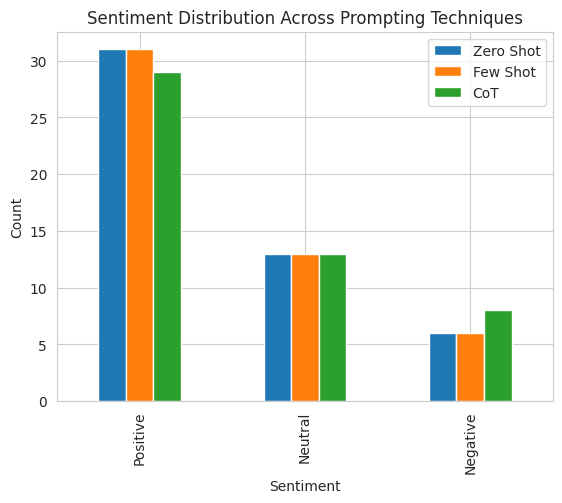

In [139]:
import pandas as pd
import matplotlib.pyplot as plt

# Count sentiment values for each prompting technique
sentiment_distribution = pd.DataFrame({
    'Zero Shot': sample_df['V2_zero_shot_Sentiment'].value_counts(),
    'Few Shot': sample_df['V2_few_shot_Sentiment'].value_counts(),
    'CoT': sample_df['V2_CoT_Sentiment'].value_counts()
}).fillna(0)

# Plot bar chart
sentiment_distribution.plot(kind='bar')

# Labels
plt.title('Sentiment Distribution Across Prompting Techniques')
plt.xlabel('Sentiment')
plt.ylabel('Count')

# Show plot
plt.show()

**Observation:** it is even across the 3 methods for their sentiment predictions

##  **Comparison of Prompting Techniques:**
    
   *   How do the three techniques (Zero-Shot, Few-Shot, CoT) compare in terms of their responses. Use LLM to give verdict?
        
  *   Which technique was the most reliable and consistent? Why do you think it performed the best?
        
   *   What model and prompt design would you propose for a production environment?
        


In [140]:
#combine al insights from each model into a single string per model
zero_shot_insights = "\n".join(sample_df['V2_zero_shot_Retail_Insight'].astype(str).tolist())
few_shot_insights = "\n".join(sample_df['V2_few_shot_Retail_Insight'].astype(str).tolist())
cot_insights = "\n".join(sample_df['V2_CoT_Retail_Insight'].astype(str).tolist())

In [141]:
#build a prompt to compare the responses from the 3 different techniques
final_prompt = f'''
You are evaluating three prompting techniques used for retail review analysis.
Retail Insight Examples (all available insights):

Zero-Shot Insights:
{zero_shot_insights}

Few-Shot Insights:
{few_shot_insights}

Chain-of-Thought Insights:
{cot_insights}

Explain:
1. How the three techniques compare overall
3. Which model produced the strongest retail insights
4. Which prompt design is best for production

Return concise, business-ready conclusions.
'''

In [142]:
response = client.chat.completions.create(
    model=model,
    messages=[{"role": "system", "content": final_prompt}],
    temperature=0
)

print(response.choices[0].message.content)

1. Overall Comparison: All three techniques - Zero-Shot, Few-Shot, and Chain-of-Thought - provide valuable insights for retail review analysis. Zero-Shot insights are direct and straightforward, focusing on specific product features and customer feedback. Few-Shot insights are more detailed, providing a broader context and more nuanced understanding of customer feedback. Chain-of-Thought insights are the most comprehensive, providing a detailed analysis of customer feedback and suggesting specific actions for improvement.

2. Strongest Retail Insights: The Chain-of-Thought model produced the strongest retail insights. It not only identified the issues or positive aspects mentioned in the reviews but also provided actionable recommendations for improvement or maintaining the praised aspects. This model's insights are more strategic and can be directly incorporated into business decisions.

3. Best Prompt Design for Production: The best prompt design for production would be the Chain-of-

1. Overall Comparison: All three techniques - Zero-Shot, Few-Shot, and Chain-of-Thought - provide valuable insights for retail review analysis. Zero-Shot insights are direct and straightforward, focusing on specific product features and customer feedback. Few-Shot insights are more detailed, providing a broader context and more nuanced understanding of customer feedback. Chain-of-Thought insights are the most comprehensive, providing a detailed analysis of customer feedback and suggesting specific actions for improvement.

2. Strongest Retail Insights: The Chain-of-Thought model produced the strongest retail insights. It not only identified the issues or positive aspects mentioned in the reviews but also provided actionable recommendations for improvement or maintaining the praised aspects. This model's insights are more strategic and can be directly incorporated into business decisions.

3. Best Prompt Design for Production: The best prompt design for production would be the Chain-of-Thought model. While it may require more computational resources due to its detailed analysis, the insights it provides are actionable and directly tied to business outcomes. This model can help businesses make informed decisions about product design, quality control, pricing strategy, and marketing, ultimately leading to improved customer satisfaction and increased sales.

In [143]:
print("Zero Shot variability:", sample_df['V2_zero_shot_judge_score'].std())
print("Few Shot variability:", sample_df['V2_few_shot_judge_score'].std())
print("CoT variability:", sample_df['V2_CoT_judge_score'].std())

print("Zero Shot mean:", sample_df['V2_zero_shot_judge_score'].mean())
print("Few Shot mean:", sample_df['V2_few_shot_judge_score'].mean())
print("CoT mean:", sample_df['V2_CoT_judge_score'].mean())

Zero Shot variability: 0.07845341787016168
Few Shot variability: 0.0790205346600438
CoT variability: 0.07064975410503593
Zero Shot mean: 0.9495999999999999
Few Shot mean: 0.9491999999999998
CoT mean: 0.9438


### **Observations and Insights**

 **Refined Insights:**
    
   *   What are the most meaningful and recurring insights from the customer reviews, as identified by your best-performing model?

In [144]:
#prompt to find what the most meaningful and recurring insights from the CoT model
refined_insight_prompt = f'''
You are a retail business analyst. You have a list of retail insights generated by a Chain-of-Thought AI model from multiple customer reviews.

Your task is to:

1. Identify the **most meaningful insights** that occur repeatedly across the reviews.
2. Summarize the recurring themes or patterns.
3. Highlight actionable points that the retail team could use to improve products, service, or customer experience.

provide your answer in 3 lines, one for each task.

Here are the insights to analyze:

{cot_insights}

'''

In [145]:
response = client.chat.completions.create(
    model=model,
    messages=[{"role": "system", "content": refined_insight_prompt }],
    temperature=0
)

print(response.choices[0].message.content)

1. The most meaningful insights recurring across the reviews are issues with sizing and fit, quality concerns, and price dissatisfaction. Customers also appreciate versatile, well-designed, and high-quality products.

2. The recurring themes are the need for accurate sizing and fit for different body types, maintaining high product quality, and ensuring pricing aligns with customer expectations. Positive feedback highlights the importance of versatile, well-designed, and quality products.

3. Actionable points for the retail team include reviewing and adjusting sizing guides to cater to different body types, improving quality control processes, and revising pricing strategies if necessary. The team should also focus on maintaining and promoting the features of products that receive positive feedback, such as versatility, design, and quality.


1. The most meaningful insights recurring across the reviews are issues with sizing and fit, quality concerns, and price dissatisfaction. Customers also appreciate versatile, well-designed, and high-quality products.

2. The recurring themes are the need for accurate sizing and fit for different body types, maintaining high product quality, and ensuring pricing aligns with customer expectations. Positive feedback highlights the importance of versatile, well-designed, and quality products.

3. Actionable points for the retail team include reviewing and adjusting sizing guides to cater to different body types, improving quality control processes, and revising pricing strategies if necessary. The team should also focus on maintaining and promoting the features of products that receive positive feedback, such as versatility, design, and quality.

# Generating Actionable Product Improvement Suggestions


 *   Based on the aggregated insights from your best model, what are 3 short-term (3-6 months) and 3 long-term (6-12 months) actionable business recommendations for the retail company?
        
 *   How does this automated GenAI pipeline solve the initial business problem and create value?

In [146]:
business_action_prompt=f'''
You are a retail business strategist. You have a list of retail insights generated by the Chain-of-Thought (CoT) model from multiple customer reviews.

Your task is to generate **actionable business recommendations** based on these insights.

Instructions:

1. Analyze the insights carefully using a Chain-of-Thought reasoning approach.
2. Identify recurring themes, problems, or opportunities across the reviews.
3. Based on the aggregated insights, provide:
   - **3 short-term actionable recommendations (3-6 months)**
   - **3 long-term actionable recommendations (6-12 months)**
4. Each recommendation should be concise, actionable, and business-focused.

Here are the aggregated CoT insights to consider:

{cot_insights}

Format your response like this:

Short-Term Recommendations:
1. ...
2. ...
3. ...

Long-Term Recommendations:
1. ...
2. ...
3. ...

'''

In [147]:
response = client.chat.completions.create(
    model=model,
    messages=[{"role": "system", "content": business_action_prompt }],
    temperature=0
)

print(response.choices[0].message.content)

Short-Term Recommendations:
1. Review and revise the sizing guides for all products, particularly blouses, pants, dresses, and leggings. This will address the recurring issue of sizing dissatisfaction among customers and potentially reduce return rates.
2. Improve product descriptions and images to accurately represent the products. This will manage customer expectations and reduce potential returns due to discrepancies between the product and its description.
3. Review the pricing strategy for casual tees and other products perceived as overpriced by customers. Consider offering sales or discounts to attract customers and align prices with customer expectations and market standards.

Long-Term Recommendations:
1. Invest in quality control processes to ensure the quality of products matches their price. This will maintain customer satisfaction and the company's reputation. Particular attention should be paid to the quality of leggings and blouses, which have been highlighted as areas f

### **Observations and Insights**

Short-Term Recommendations:
1. Review and revise the sizing guides for all products, particularly blouses, pants, dresses, and leggings. This will address the recurring issue of sizing dissatisfaction among customers and potentially reduce return rates.
2. Improve product descriptions and images to accurately represent the products. This will manage customer expectations and reduce potential returns due to discrepancies between the product and its description.
3. Review the pricing strategy for casual tees and other products perceived as overpriced by customers. Consider offering sales or discounts to attract customers and align prices with customer expectations and market standards.

Long-Term Recommendations:
1. Invest in quality control processes to ensure the quality of products matches their price. This will maintain customer satisfaction and the company's reputation. Particular attention should be paid to the quality of leggings and blouses, which have been highlighted as areas for improvement.
2. Continue producing and promoting products that have received positive feedback, such as the swim suit, jacket, and blouse. Consider expanding the color range and size options for these popular items to cater to a wider range of customer preferences.
3. Incorporate customer feedback into future product designs. This includes offering a variety of fits for different body shapes, considering different body proportions when designing blouses and dresses, and improving the fabric quality of t-shirts. This will enhance customer satisfaction and potentially increase sales.

## **Conclusion**

By automatically structuring, evaluating, and summarizing customer feedback, the GenAI pipeline turns unstructured reviews into real-time, actionable business intelligence—speeding up response times, improving products, and enhancing customer satisfaction.